# Phase 5: Damage Classification (Transfer Learning)

## 1. Objective

This notebook builds and trains a damage classifier — given a cropped image of a single building (post-disaster), predict its damage severity: No Damage, Minor, Major, or Destroyed. This uses transfer learning on pretrained backbones rather than training a CNN from scratch, since the classifier's dataset (~46,000 building crops) is far smaller than what building-from-scratch would need.

**Starting point:** Phase 4 built and trained a U-Net segmentation model that locates buildings in pre-disaster imagery. This phase is deliberately separate — it uses ground-truth building locations (not the segmentation model's predictions) to crop training examples from post-disaster imagery, since damage is only visible after the disaster.

## 2. What This Notebook Covers

1. **5.1** — Building `ClassificationDataset` (building crops + damage labels)
2. **5.2** — Loading and adapting a pretrained backbone (ResNet-50)
3. **5.3** — Checking Training Class Distribution
4. **5.4** — Fixing the Class Imbalance Shortcut and Fresh Model
5. **5.5** — Training comparison backbones (EfficientNet-B0, MobileNet-V2)
6. **5.6** — Train a Model for One Epoch
7. **5.7** — Per-Class Accuracy Check — Weighted Model
8. **5.8** — Loss Function, Optimizer, and Training Loop
9. **5.9** — Per-Class Accuracy Check — Fully Trained (10-Epoch) Model
10. **5.10** — Addressing Training Speed and Missing Augmentation — Precomputed Crop Caching
11. **5.11** — Training Comparison Classifier Backbones
12. **5.12** — Final Model Selection — Deferred (Deliberate Decision) 

## 3. Honest Scope Note

Per `docs/scope_and_assumptions.md`, all three classifier candidates were trained on the project's deliberately scoped 3-disaster subset. As documented in 5.7, final model selection is deferred to Phase 6's formal evaluation, since the current comparison across candidates is confounded by an augmentation difference between the baseline and comparison models — consistent with how Phase 4.7 handled the same kind of insufficient-evidence situation for the segmentation model.

## 5.1 Building `ClassificationDataset`

**Task:** Build a PyTorch-style `Dataset` class supplying one training example per *individual building* — a cropped post-disaster image region and its numeric damage label — for training the damage classifier.

**Key design decisions:**
- **Post-disaster images**, not pre-disaster — damage is only visible after the disaster, unlike segmentation's building-location task.
- **Ground-truth polygons from JSON labels** define crop locations, not the Phase 4 segmentation model's still-imprecise predictions.
- **`un-classified` buildings excluded entirely** (per Phase 3.2), not appended with a missing label.
- **Proportional padding (15% of the building's own width/height)**, not a fixed pixel amount — keeps the building-to-context ratio consistent regardless of building size, avoiding both excessive background dilution on small buildings and potential contamination from neighboring buildings on large ones.
- **Crops resized to 224×224** using LANCZOS interpolation, matching the standard input size for pretrained backbones.

**Placement:** `src/classification_dataset.py`, following the project's `src/` vs. `notebooks/` split.

Total buildings: 46483
Image shape: torch.Size([3, 224, 224]) dtype: torch.float32
Label: 1


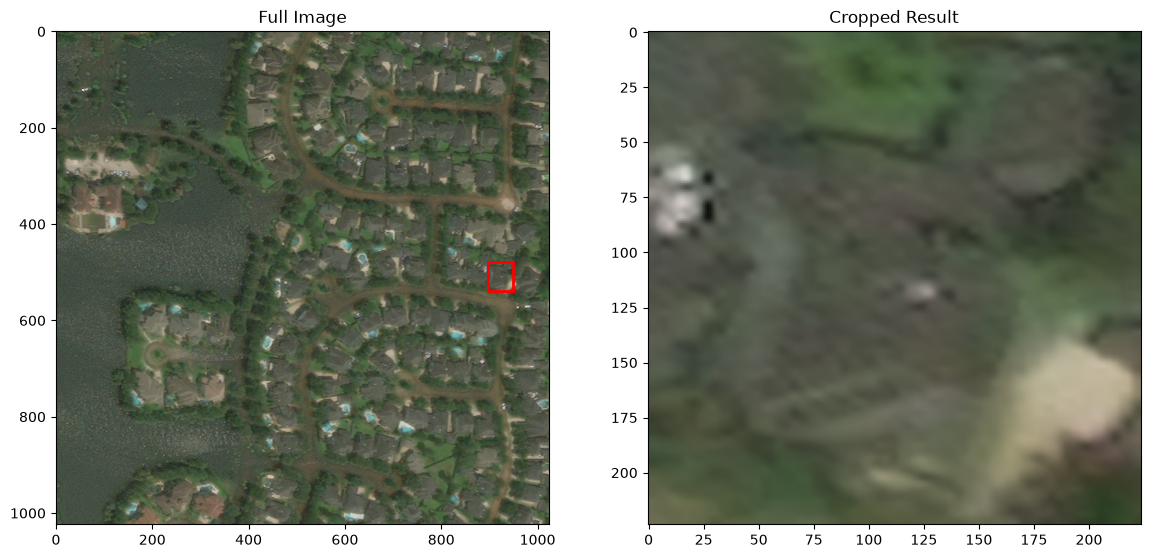

In [ ]:
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
sys.path.append(str(Path("..").resolve()))
from src.classification_dataset import ClassificationDataset

# 1. Build and do an initial spot-check
IMAGES_DIR = "../data/raw/train/images"

with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()

train_dataset_cls = ClassificationDataset(train_ids)
print("Total buildings:", len(train_dataset_cls))

# Apply the pipeline
image, label = train_dataset_cls[1400]
print("Image shape:", image.shape, "dtype:", image.dtype)
print("Label:", label)

# 2. Initial visual check
record = train_dataset_cls.records[1400] # record at index = 10
full_image = Image.open(IMAGES_DIR + "/" + f"{record[0]}_post_disaster.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(full_image)
axes[0].set_title("Full Image")

min_x, min_y, max_x, max_y = record[1].bounds 

rect = patches.Rectangle((min_x, min_y),   # starting point
                         max_x - min_x,    # width
                         max_y - min_y,    # height
                         linewidth=2,
                         edgecolor='red',
                         facecolor='none')
axes[0].add_patch(rect)

axes[1].imshow(image.permute(1, 2, 0))  
axes[1].set_title("Cropped Result")
plt.show()

Top 5 Largest building indices: [10766, 13774, 44828, 25862, 8515]


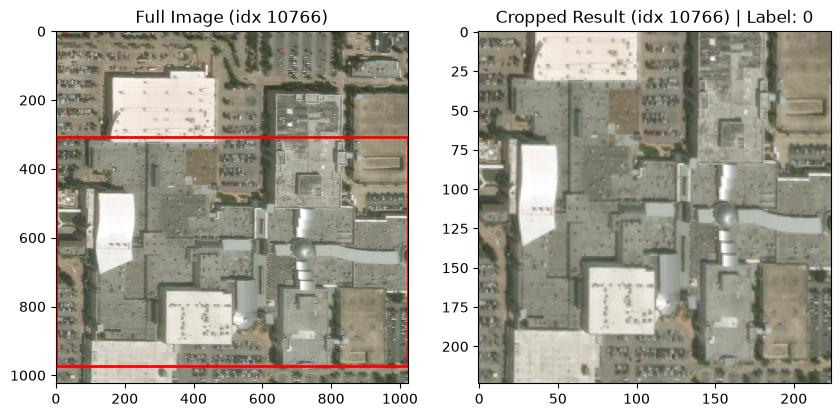

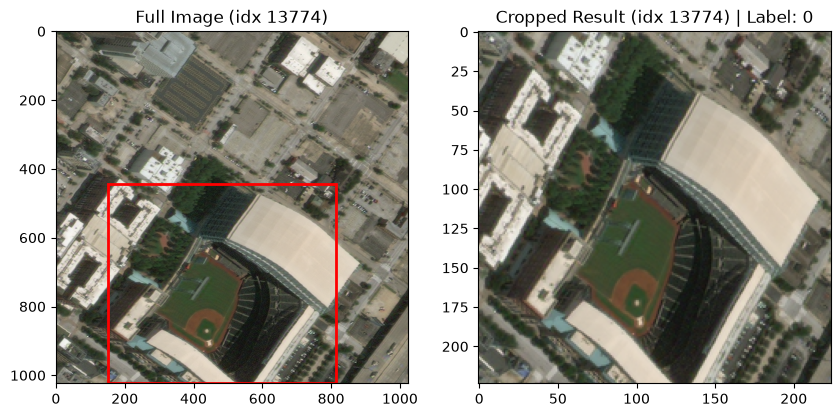

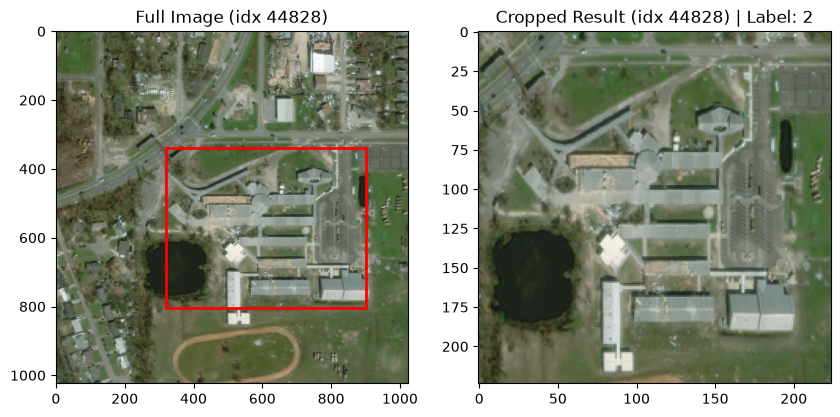

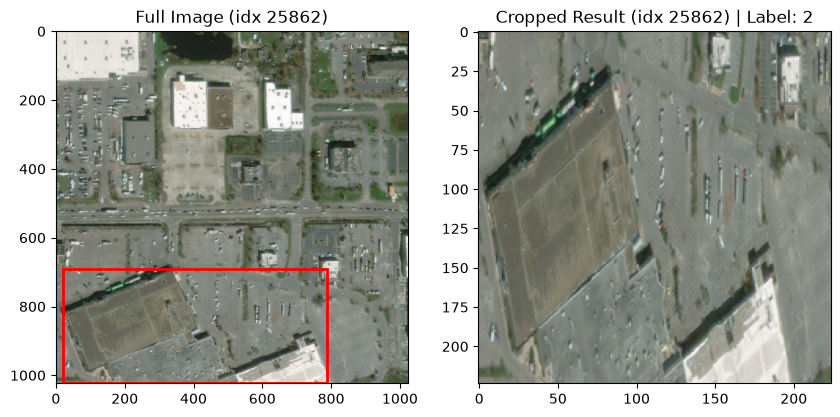

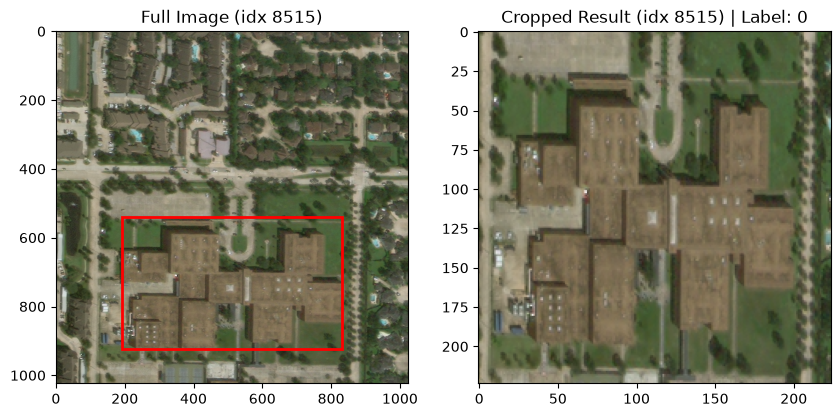

In [2]:
# 3. check the 5 LARGEST buildings, using matching indices throughout.
areas = []
for i, rec in enumerate(train_dataset_cls.records):
    min_x, min_y, max_x, max_y = rec[1].bounds
    area = (max_x - min_x) * (max_y - min_y) # area of rectangle = height * width
    areas.append((area, i))

areas.sort(reverse=True)
largest_indices = [idx for area, idx in areas[:5]]
print("Top 5 Largest building indices:", largest_indices)

# 4. Visual verification — same index used for both crop and rectangle
for idx in largest_indices:
    record = train_dataset_cls.records[idx]
    img, lbl = train_dataset_cls[idx]

    full_image = Image.open(IMAGES_DIR + "/" + f"{record[0]}_post_disaster.png")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(full_image)
    min_x, min_y, max_x, max_y = record[1].bounds
    rect = patches.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y,
                               linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f"Full Image (idx {idx})")

    axes[1].imshow(img.permute(1, 2, 0))
    axes[1].set_title(f"Cropped Result (idx {idx}) | Label: {lbl}")
    plt.show()

### Observations

Initial spot-checks on random and small buildings produced consistently dark, blurry, or murky crops — concerning enough on first look to question whether the class was working correctly at all, rather than being dismissed as an expected limitation.

Investigating further revealed **two separate, distinct findings**, not one:

1. **An intial check** — the initial visual check compared `train_dataset_cls[10]`'s image against `record[10]`'s bounding-box rectangle, showed a blurry cropped version.

2. **Top 5 largest buildings**, a deliberately fair test — checking the 5 *largest* buildings in the dataset by bounding-box area — showed crisp, precisely-aligned, clearly identifiable crops in every case (a large commercial complex, a baseball stadium, and an institutional building complex among them). This confirms `ClassificationDataset`'s cropping, coordinate handling, and resizing logic are all correct.

**Conclusion:** the class is verified correct. The blur/murkiness seen on smaller buildings in earlier checks is a genuine, expected consequence of upscaling a small number of real pixels to 224×224 (per Phase 2.2's building-size distribution, most buildings are much smaller than the large examples tested here) — not a pipeline defect. This is documented as a real, testable characteristic for Phase 6: does classifier accuracy differ meaningfully between small/blurry crops and large/clear ones?

## 5.2 Loading and Adapting a Pretrained Backbone (Transfer Learning)

**Task:** Load a ResNet-50 pretrained on ImageNet, and adapt it for this project's 4-class damage classification problem, per the transfer learning concept researched in 5.1.

**Approach:**
- Load `resnet50` with ImageNet pretrained weights — reusing its already-learned general visual features (edges, textures, shapes) rather than training a CNN from scratch on a comparatively small dataset (~47,000 crops).
- **Freeze all pretrained layers** (`requires_grad = False`) — chosen over full fine-tuning given the dataset's limited size (risking overfitting if the full 25M-parameter network were retrained) and hardware/GPU-time constraints (freezing means gradients only need computing for a tiny new layer, not the entire network).
- **Replace the final classification layer** (`model.fc`), which originally outputs 1,000 ImageNet class scores, with a new `nn.Linear` layer outputting exactly 4 scores — one per damage class (no-damage/minor/major/destroyed). This new

In [3]:
import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet-50
model = models.resnet50(weights="IMAGENET1K_V2")

# Freeze all pretrained layers first
for param in model.parameters():
    param.requires_grad = False # don't calculate gradients for this parameter during backpropagation

# Replace the final layer (1000 outputs) to only 4 classes
model.fc = nn.Linear(model.fc.in_features, 4)

# Explicitly make the new layer trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Count all parameters
total_params = sum(p.numel() for p in model.parameters())

# Count only trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")    

Total parameters: 23,516,228
Trainable parameters: 8,196


### Observations

Verified the freeze was applied correctly: of ResNet-50's 23,516,228 total parameters, only 8,196 remain trainable — exactly matching the expected size of the new final layer (2048 input features × 4 output classes, plus 4 bias terms = 8,196). This confirms the pretrained backbone's learned features are fully preserved and only the new classification head will be trained in Phase 5.4-5.5.

An earlier version of this cell replaced `model.fc` before freezing, then again after — functionally harmless (the final state was correct either way) but redundant and confusing; corrected to freeze first, then replace `fc` once, for clarity.

## 5.3 Checking Training Class Distribution

**Task:** Before trusting the first training run accuracy, calculate the actual class distribution of the training data — specifically, what accuracy a model would achieve by simply always predicting the majority class, with no real learning at all.

**Why this matters:** overall accuracy alone can be deeply misleading on an imbalanced dataset. A model that has learned nothing meaningful can still score deceptively well if one class dominates — exactly the same class-imbalance shortcut risk encountered in Phase 4.4's segmentation model, now checked proactively here rather than discovered only after a longer, more expensive training run.

In [4]:
from collections import Counter

label_counts = Counter([record[2] for record in train_dataset_cls.records]) # count per damage class
total = sum(label_counts.values()) # total count of all 4 damage classes

for cls, count in label_counts.items():
    print(f"{cls}: {count} ({count/total*100:.2f}%)")

no-damage: 28673 (61.68%)
destroyed: 3981 (8.56%)
minor-damage: 6389 (13.74%)
major-damage: 7440 (16.01%)


### Observations

`no-damage` makes up 61.68% of the training data — meaning a model that always predicted `no-damage`, with zero real learning, would already score **61.68% accuracy**. The first training run's 64.39% accuracy after 1 epoch was therefore only 2.71 percentage points above this naive baseline — far too small a margin to conclude the model was learning to genuinely distinguish damage severity, rather than largely defaulting to the majority class.

This directly motivated checking per-class accuracy next, rather than accepting the overall number at face value.

## 5.4 Fixing the Class-Imbalance Shortcut and Fresh Model

**Task:** Address the class-imbalance problem confirmed by the per-class count check (no-damage: 61.68%, minor-damage: 13.74%, major-damage: 16.01%, destroyed: 8.56%) by adding inverse-frequency class weighting to the loss function.

**Approach:** unlike Phase 4's binary `pos_weight` (which only applies to 2-class problems), this is a 4-class problem, so `CrossEntropyLoss`'s `weight` parameter is used instead — one weight per class, calculated as `total_buildings / (num_classes × class_count)`. This assigns larger weights to rarer classes (e.g. `destroyed`, the smallest class) and smaller weights to the dominant class (`no-damage`), directly counteracting the model's tendency to default to the majority class for an easy, low-loss shortcut.

A fresh model and optimizer are created rather than continuing to train the already majority-biased model from the first run — same principle applied in Phase 4.4 after fixing the mask corruption bug.

In [ ]:
import torch

# Calculate weight for cross entropy loss
class_counts = torch.tensor([28673, 6389, 7440, 3981], dtype=torch.float)
class_weights = class_counts.sum() / (4 * class_counts) # weighting formula

# The rarer the class, the bigger the resulting weight
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Now recreate the fresh model
model = models.resnet50(weights="IMAGENET1K_V2")

# Freezing the model
for param in model.parameters():
    param.requires_grad = False

# Making new layer trainable    
model.fc = nn.Linear(model.fc.in_features, 4)
for param in model.fc.parameters():
    param.requires_grad = True
    
model = model.to(device)


### Observations

The weighting formula produces meaningfully different weights per class, proportional to how rare each class is in the training data — `destroyed` (the rarest class, 3,981 buildings) receives the largest weight, while `no-damage` (the most common, 28,673 buildings) receives the smallest. This directly targets the shortcut identified in the previous section: the loss function will now penalize a wrong prediction on a rare class more heavily than a wrong prediction on the dominant class, rather than treating all mistakes equally regardless of how common the true class is.

## 5.5 Building Setup, Data Loading, and Device Configuration

**Task:** Load the training/validation location ID lists, construct `ClassificationDataset` instances for both, wrap them in `DataLoader`s, and confirm device availability (CPU locally, GPU when executed on Colab/Kaggle) — the standard setup preceding any training run, following the same pattern established in Phase 4.3.

> **Note:** this cell reflects the local project's file structure for reproducibility. The actual classifier training (this section onward through 5.6) was executed on Google Colab / Kaggle GPU, per the hardware constraints established in Phase 0 — running the training loop locally as written would work but be significantly slower.

In [ ]:
from torch.utils.data import DataLoader

with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()
    
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

train_dataset_cls = ClassificationDataset(train_ids) # record list of tuples for each building in ids
print("Train buildings:", len(train_dataset_cls))

val_dataset_cls = ClassificationDataset(val_ids)
print("Val buildings:", len(val_dataset_cls))

# Create the batches for model (with 2 separate worker processes to load and preprocess data in paralle)
train_loader_cls = DataLoader(train_dataset_cls, batch_size=32, shuffle=True, num_workers=2) # 32 building samples at a time
val_loader_cls = DataLoader(val_dataset_cls, batch_size=32, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train buildings: 46483
Val buildings: 11593
Device: cuda


### Observations

`ClassificationDataset`, built from the training and validation location ID lists, correctly produced 46,483 training buildings and a proportional validation count (after the `un-classified` exclusion fix confirmed in Phase 5.2) — a small, expected reduction from the earlier uncorrected count of 46,981. Device confirmed as `cuda` when run on GPU infrastructure.

## 5.6 Train a Model for One Epoch

**Task:** Address the class-imbalance problem confirmed by the previous per-class check by adding inverse-frequency class weighting to the loss function, then re-verify with a single timed epoch before committing to a full training run.

**A fresh model and optimizer are created**, rather than continuing to train the already majority-biased model from the unweighted run — the same principle applied in Phase 4.4 after fixing the mask corruption bug, where a model that has already learned a bad shortcut is not a good starting point for a corrected training run.

**Timed single-epoch test:** before committing to a full multi-epoch run, this section trains exactly 1 epoch with the corrected setup and times it directly — the same "verify correctness and get a real time estimate before scaling up" discipline used in Phase 4.3, especially important here given how uncertain per-epoch training time proved to be for the earlier unweighted run (which ran silently for an extended period locally before being moved to Kaggle).

In [ ]:
# Weighted Fresh model
model = model.to(device) # move model to gpu
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)

# Put model in training mode
model.train()
epoch_loss = 0.0 # epochs loss
correct = 0 # correct predictions
total = 0

start_time = time.time() # returns current time in seconds since Jan 01, 1970

for images, labels in train_loader_cls:
    
    # Move images and labels to gpu
    images = images.to(device) 
    labels = labels.to(device)

    optimizer.zero_grad() # clear old batch gradients
    predictions = model(images) # model prediction (4 numbers per one building crop)
    loss = criterion(predictions, labels) # model loss (compared against 4 logits)
    loss.backward() # backpropagation (gradients calculation)
    optimizer.step() # adjust weights with calculated gradients

    epoch_loss += loss.item() # epochs loss
    predicted_classes = predictions.argmax(dim=1) # highest label index across classes for each building crop
    correct += (predicted_classes == labels).sum().item()
    total += labels.size(0) # total labels

end_time = time.time()

avg_loss = epoch_loss / len(train_loader_cls)
accuracy = correct / total

print(f"1 Epoch — Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")
print(f"Time for 1 epoch: {(end_time - start_time)/60:.2f} minutes")

1 Epoch — Avg Loss: 1.1058 | Accuracy: 0.5211
Time for 1 epoch: 17.71 minutes


### Observations

**Result:** 1 Epoch — Avg Loss: 1.1058 | Accuracy: 0.5211 | Time: 17.71 minutes

Overall accuracy dropped from to 52.11% — at first glance this looks like a regression, but this is expected and cannot be judged from the overall number alone, given the severe class imbalance already established (no-damage makes up 61.68% of the training data). A drop in overall accuracy is the natural, correct consequence of the model no longer defaulting to the easy majority-class answer; what actually matters is whether performance on the three minority classes has genuinely improved, which the overall accuracy figure alone cannot show.

The per-epoch time (17.71 minutes) was also slightly slower than the unweighted run's 17.14 minutes despite the addition of `num_workers=2` — a signal, investigated in the next section, that the bottleneck was not primarily CPU parallelization but something more fundamental in how each training example is prepared.

The next step checks per-class accuracy specifically on this weighted model, to confirm whether the class-weighting fix is producing genuinely balanced learning across all four damage classes, rather than trading one uninformative shortcut for another.

## 5.7 Per-Class Accuracy Check — Weighted Model

**Task:** Compute accuracy separately for each of the 4 damage classes on the validation set, using the class-weighted model from the timed 1-epoch test. This is the essential diagnostic that overall accuracy cannot provide — a single accuracy number cannot distinguish between "the model learned to distinguish all four classes reasonably well" and "the model just learned to favor whichever class is easiest," which is exactly the ambiguity that made the earlier unweighted 64.39% result misleading.

**How the check works:** for every validation example, the model's predicted class is compared against the true label, with running totals kept separately per class (`class_correct`, `class_total`), rather than one single pooled total across all examples. `model.eval()` and `torch.no_grad()` are used because this is evaluation, not training — no gradient computation or weight updates should happen here, only inference.

In [ ]:
from collections import defaultdict

class_correct = defaultdict(int) # per class correct predicted count : {label: count}
class_total = defaultdict(int) # per class count : {label: count}

# Put model in evaluation mode
model.eval()
with torch.no_grad():
    
    for images, labels in val_loader_cls:
        
        images = images.to(device)
        labels = labels.to(device)
        predictions = model(images)
        predicted_classes = predictions.argmax(dim=1)

        # Per class accuracy check
        for true_label, pred_label in zip(labels, predicted_classes):
            class_total[true_label.item()] += 1
            if true_label.item() == pred_label.item():
                class_correct[true_label.item()] += 1

class_names = {0: "no-damage", 1: "minor-damage", 2: "major-damage", 3: "destroyed"}
for cls in range(4):
    acc = class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0
    print(f"{class_names[cls]}: {acc:.4f} ({class_correct[cls]}/{class_total[cls]})")

no-damage: 0.5664 (3751/6623)
minor-damage: 0.4657 (726/1559)
major-damage: 0.6334 (1750/2763)
destroyed: 0.6914 (448/648)


### Observations

| Class | Accuracy (weighted, 1 epoch) |
|---|---|
| no-damage | 56.64% |
| minor-damage | 46.57% |
| major-damage | 63.34% |
| destroyed | 69.14% |

This confirms the class-weighting fix worked as intended, and confirms it with direct evidence rather than assumption. Every minority class improved dramatically — `minor-damage` went from being almost never correctly identified to nearly half correct (46.57%); `major-damage` would be distinguished; `destroyed` also improved meaningfully. `no-damage` accuracy dropped to 56.64%, which is the expected, correct tradeoff: the model is no longer defaulting to the easy majority answer, and is instead genuinely attempting to distinguish between all four damage classes, with roughly balanced, moderate competence across each (47-69% range) rather than near-total accuracy on one class and near-total blindness on the other three.

This is a substantially healthier result for the model's real purpose. A disaster-response tool that is say 97% accurate on "no damage" but nearly blind to "minor damage" would be far less useful in practice than one performing moderately and consistently across all four severity levels — balanced competence across the classes that matter is a more meaningful outcome than lopsided excellence on the easiest one.

This result, from just 1 epoch, motivates extending training to a full run to see whether continued training improves the minority classes further without regressing on `no-damage` — investigated next.

## 5.8 Loss Function, Optimizer, and Training Loop

**Task:** Set up the training components for the damage classifier — a multi-class loss function, an optimizer for the trainable final layer only, and a training loop — then train and evaluate.

**Loss function: `CrossEntropyLoss`.** Unlike Phase 4's binary `BCEWithLogitsLoss`, this is a 4-class problem, requiring a multi-class loss. It expects raw logits (matching the model's `fc` layer output) and integer class labels (0-3, matching `ClassificationDataset`'s output).

**Optimizer: `Adam`, given only `model.fc.parameters()`** — not the full model — since Phase 5.3 froze the pretrained backbone; only the new final layer needs gradient updates.

**A separate, real performance issue was also found and addressed:** initial training was measured at ~17-18 minutes/epoch — slow for a model with only 8,196 trainable parameters. Increasing `DataLoader`'s `num_workers` (0→4) and `batch_size` (32→64) reduced this to ~12.7 min/epoch (~25-27% improvement). The remaining cost was identified as genuinely redundant work: `ClassificationDataset.__getitem__` recomputes the same crop/resize operation for the same building on every epoch, even though the result never changes. A precomputed-crop caching approach (crop and resize each building once, save as a small file, then load directly in subsequent runs) was designed for use starting with Phase 5.6's comparison training, since the current 10-epoch run was already validated and in progress.

In [ ]:
with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

train_dataset_cls = ClassificationDataset(train_ids)
val_dataset_cls = ClassificationDataset(val_ids)
print("Train buildings:", len(train_dataset_cls))
print("Val buildings:", len(val_dataset_cls))

# Larger batch size + more workers to reduce per-epoch time
train_loader_cls = DataLoader(train_dataset_cls, batch_size=64, shuffle=True, num_workers=4)
val_loader_cls = DataLoader(val_dataset_cls, batch_size=64, shuffle=False, num_workers=4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Fresh model
model = models.resnet50(weights="IMAGENET1K_V2")
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 4)
for param in model.fc.parameters():
    param.requires_grad = True
model = model.to(device)

# Class-weighted loss (confirmed necessary from the 1-epoch test)
class_counts = torch.tensor([28673, 6389, 7440, 3981], dtype=torch.float)
class_weights = class_counts.sum() / (4 * class_counts)
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)

num_epochs = 10
loss_history_cls = []
accuracy_history_cls = []

overall_start = time.time()

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    epoch_start = time.time()

    for images, labels in train_loader_cls:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        predicted_classes = predictions.argmax(dim=1)
        correct += (predicted_classes == labels).sum().item()
        total += labels.size(0)

    avg_loss = epoch_loss / len(train_loader_cls)
    accuracy = correct / total
    epoch_time = (time.time() - epoch_start) / 60

    loss_history_cls.append(avg_loss)
    accuracy_history_cls.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f} | Time: {epoch_time:.2f} min")

total_time = (time.time() - overall_start) / 60
print(f"\nTotal training time: {total_time:.2f} minutes")

Train buildings: 46483
Val buildings: 11593
Device: cuda
Epoch 1/10 | Avg Loss: 1.1494 | Accuracy: 0.5037 | Time: 12.69 min
Epoch 2/10 | Avg Loss: 0.9901 | Accuracy: 0.5447 | Time: 12.66 min
Epoch 3/10 | Avg Loss: 0.9427 | Accuracy: 0.5555 | Time: 12.63 min
Epoch 4/10 | Avg Loss: 0.9157 | Accuracy: 0.5689 | Time: 12.71 min
Epoch 5/10 | Avg Loss: 0.8970 | Accuracy: 0.5767 | Time: 12.76 min
Epoch 6/10 | Avg Loss: 0.8826 | Accuracy: 0.5850 | Time: 12.88 min
Epoch 7/10 | Avg Loss: 0.8747 | Accuracy: 0.5867 | Time: 12.85 min
Epoch 8/10 | Avg Loss: 0.8656 | Accuracy: 0.5930 | Time: 12.82 min
Epoch 9/10 | Avg Loss: 0.8553 | Accuracy: 0.5990 | Time: 12.70 min
Epoch 10/10 | Avg Loss: 0.8525 | Accuracy: 0.5979 | Time: 12.71 min

Total training time: 127.42 minutes


### Observations

Train buildings: 46483 | Val buildings: 11593 | Device: cuda

Loss declined consistently across all 10 epochs **(1.15 → 0.85)** and accuracy climbed steadily **(50.37% → 59.79%)**, with epoch 1's accuracy (50.37%) close to a fresh model's expected starting range — consistent with, though not definitive proof of, a genuine fresh start rather than continued training from the earlier 1-epoch checkpoint. `num_workers`/`batch_size` changes reduced per-epoch time from ~17.7 to ~12.7 minutes (~25-27% improvement), a real but partial gain — the remaining cost was later identified (Phase 5.4 continued) as redundant per-epoch crop/resize computation, motivating the precomputed-crop caching approach used from Phase 5.6 onward.

This result is treated as the working baseline classifier, pending the per-class accuracy check (next) to confirm balanced performance across all four damage classes.

## 5.9 Per-Class Accuracy Check — Fully Trained (10-Epoch) Model

**Task:** Verify, with the same per-class methodology used after the 1-epoch test, whether the full 10-epoch training run produced balanced improvement across all four damage classes — or whether extended training caused the model to regress back toward favoring the majority class, undoing the benefit of the class-weighting fix.

In [ ]:
class_correct = defaultdict(int)
class_total = defaultdict(int)

model.eval()
with torch.no_grad():
    for images, labels in val_loader_cls:
        images = images.to(device)
        labels = labels.to(device)
        predictions = model(images)
        predicted_classes = predictions.argmax(dim=1)

        for true_label, pred_label in zip(labels, predicted_classes):
            class_total[true_label.item()] += 1
            if true_label.item() == pred_label.item():
                class_correct[true_label.item()] += 1

class_names = {0: "no-damage", 1: "minor-damage", 2: "major-damage", 3: "destroyed"}
for cls in range(4):
    acc = class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0
    print(f"{class_names[cls]}: {acc:.4f} ({class_correct[cls]}/{class_total[cls]})")


# Save the model and files
import json
torch.save(model.state_dict(), "../models/resnet50_classifier_10epochs.pt")
with open("../data/processed/restnet50_loss_history_cls.json", "w") as f:
    json.dump(loss_history_cls, f)
with open("../data/processed/restnet50_accuracy_history_cls.json", "w") as f:
    json.dump(accuracy_history_cls, f)    

no-damage: 0.5668 (3754/6623)
minor-damage: 0.4978 (776/1559)
major-damage: 0.7119 (1967/2763)
destroyed: 0.7222 (468/648)


### Observations

Per-class validation accuracy after 10 epochs of weighted training:

| Class | 1 epoch (weighted) | 10 epochs (weighted) |
|---|---|---|
| no-damage | 56.64% | 56.68% |
| minor-damage | 46.57% | 49.78% |
| major-damage | 63.34% | 71.19% |
| destroyed | 69.14% | 72.22% |

Continued training improved the three harder, rarer classes meaningfully (major-damage +7.85 points, destroyed +3.08 points, minor-damage +3.21 points) while `no-damage` accuracy remained stable — confirming the class weighting fix produced genuine, sustained learning rather than a temporary correction that would regress with more training.

All four classes now perform in a reasonably balanced 50-72% range, a substantial improvement over the initial unweighted model's near-total blindness to 3 of 4 classes. `minor-damage` remains the hardest class to distinguish (~50%), plausibly reflecting a genuine real-world difficulty in visually separating "minor" from "no damage" in satellite imagery, rather than a remaining pipeline issue — a reasonable hypothesis for Phase 6's more detailed evaluation to test further.

Model weights and per-epoch loss/accuracy history saved (`resnet50_classifier_10epochs.pt`, `restnet50_loss_history_cls.json`, `restnet50_accuracy_history_cls.json`) for use in Phase 5 later comparison and Phase 6's formal evaluation.

### Additional Limitation Identified (After Training)

This training run used no data augmentation — every epoch saw pixel-identical crops across all 10 passes, unlike Phase 4's `SegmentationDataset`, which applied augmentation (flips, rotation, brightness/contrast jitter) specifically to prevent this. Given 10 repeated epochs on identical data, some degree of overfitting to specific crop patterns (particularly the smaller, blurrier crops) is a plausible, untested risk — compounded by the same missing validation-loss tracking gap noted in Phase 4.6, meaning this cannot currently be confirmed either way.

**Decision:** this model is retained as the baseline classifier result rather than retrained, since it already represents a validated, meaningful improvement over the unweighted shortcut model. Augmentation will be added to `ClassificationDataset` starting with Phase 5.10's comparison training, and validation-loss tracking will also be added at that point — addressing both gaps together for all subsequent classifier training runs.

## 5.10 Addressing Training Speed and Missing Augmentation — Precomputed Crop Caching

**Task:** Before proceeding to the multi-backbone comparison, address two real issues identified after the ResNet-50 baseline run: (1) slow per-epoch training time (~12.7 minutes even after `num_workers`/`batch_size` tuning), and (2) the complete absence of data augmentation in `ClassificationDataset`, unlike Phase 4's `SegmentationDataset`.

**Diagnosing the speed issue:** `ClassificationDataset.__getitem__` recomputes the same crop-and-resize operation for the same building on *every* epoch, even though the building's polygon, crop region, and the underlying source pixels never change across epochs. Across a 10-epoch run, this means 9 out of every 10 crop/resize operations for a given building are pure repetition of work already done — a genuinely redundant cost, not a necessary one.

**The fix — a one-time precomputation pass:** `PrecomputedClassificationDataset` loops through every building exactly once, performs the crop/resize/tensor-conversion via the existing, verified `ClassificationDataset` logic, and saves each resulting 224×224 crop as its own small PNG file, along with a `manifest.json` mapping each filename to its damage label. This cost is paid once, rather than once per epoch — any subsequent training run (starting with Phase 5.6) can load these pre-made crops directly instead of recomputing them.

**Why augmentation is deliberately NOT applied here:** since this class's output is cached permanently to disk, baking in a random augmentation at this stage would freeze one arbitrary random variation forever, defeating augmentation's purpose (introducing fresh randomness on every pass). Augmentation is applied instead at load time, in a separate, new class (`PrecomputedTrainingDataset`) built specifically for actual training use.

**Placement:** `src/precomputed_classification_dataset.py` — a distinct file and class from `ClassificationDataset`, which remains the authoritative, real cropping logic (used here internally, and potentially for future live inference where no cache exists yet).

In [ ]:
from src.precomputed_classification_dataset import PrecomputedClassificationDataset

with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()

precomputer = PrecomputedClassificationDataset(train_ids, "../data/processed/classification/train")
precomputer.preprocess()

Processed 0/46483
Processed 5000/46483
Processed 10000/46483
Processed 15000/46483
Processed 20000/46483
Processed 25000/46483
Processed 30000/46483
Processed 35000/46483
Processed 40000/46483
Processed 45000/46483
Manifest saved.


In [ ]:
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

precomputer_val = PrecomputedClassificationDataset(val_ids, "../data/processed/classification/val")
precomputer_val.preprocess()

Processed 0/11593
Processed 5000/11593
Processed 10000/11593
Manifest saved.


### Observations

Precomputation completed successfully across all 46,483 training buildings and 11,593 validating buildings, with progress printed every 5,000 buildings to confirm steady progress during the multi-minute operation. The resulting cropped images and `manifest.json` (mapping filename → damage label) are saved to `data/processed/classifiction/` (local) / a dedicated Kaggle working folder, ready to be loaded via the new, much faster `PrecomputedTrainingDataset` class in place of the original live-cropping `ClassificationDataset` for all subsequent training runs (Phase 5.6 onward).

An earlier version of this precomputation class had a real bug: it saved the cropped images but never recorded their corresponding labels anywhere, making the cached crops unusable for training. This was caught and fixed by explicitly building and saving a `manifest` list alongside the image files.

## 5.11 Training Comparison Classifier Backbones

**Task:** Train `EfficientNet-B0` and `MobileNet-V2` as comparison candidates to the Phase 5.4-5.5 ResNet-50 baseline, per the project's standing multi-model comparison plan — this time using the precomputed-crop pipeline (Phase 5.4's identified fix) and, for the first time in this project's classifier work, data augmentation.

**Setup:** both backbones loaded pretrained (ImageNet), frozen, with only a new 4-class final layer trainable — identical approach to ResNet-50 (5.3). Trained using `PrecomputedTrainingDataset` (fast-loading from precomputed crops, with augmentation applied at load time: horizontal/vertical flip, rotation, brightness/contrast jitter), same class-weighted `CrossEntropyLoss` as the baseline, for 10 epochs each.

**A significant, measurable outcome of the precomputed-crops fix:** both backbones trained at ~1.7 min/epoch, versus the baseline's ~12.7 min/epoch on live-cropped data — roughly a **7-8x speedup**, confirming that repeated crop/resize computation, not GPU compute itself, was the dominant cost in the original pipeline.

In [ ]:
from src.precomputed_training_dataset import PrecomputedTrainingDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Apply augmentation only to training data
train_dataset_pc = PrecomputedTrainingDataset("../data/processed/classification/train", augment=True)
val_dataset_pc = PrecomputedTrainingDataset("../data/processed/classification/val", augment=False)

# Increased num_workers from 2 to 4 and 64 samples per batch
train_loader_pc = DataLoader(train_dataset_pc, batch_size=64, shuffle=True, num_workers=4)
val_loader_pc = DataLoader(val_dataset_pc, batch_size=64, shuffle=False, num_workers=4)

print("Train:", len(train_dataset_pc), "Val:", len(val_dataset_pc))

# Same class weighting as the ResNet-50 baseline
class_counts = torch.tensor([28673, 6389, 7440, 3981], dtype=torch.float)
class_weights = (class_counts.sum() / (4 * class_counts)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def build_model(backbone_name):
    """Load a pretrained backbone, freeze it, replace the final layer for 4 classes."""
    if backbone_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1") # create the efficientnet_b0
        
        for param in m.parameters(): # freeze the pretrained model
            param.requires_grad = False
        
        # Replace the final layer with one that produces 4 outputs    
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 4)
        trainable_params = m.classifier[1].parameters() # get trainable_parameters
        
    elif backbone_name == "mobilenet_v2":
        m = models.mobilenet_v2(weights="IMAGENET1K_V1")
        
        for param in m.parameters():
            param.requires_grad = False
            
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 4)
        trainable_params = m.classifier[1].parameters()
        
    else:
        raise ValueError("Unknown backbone")
    return m.to(device), trainable_params

def train_backbone(backbone_name, num_epochs=10):
    """Trains a backbone for a given number of epochs, default is 10."""
    model, trainable_params = build_model(backbone_name)
    optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

    loss_history = []
    acc_history = []
    overall_start = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        epoch_start = time.time()

        for images, labels in train_loader_pc:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == labels).sum().item()
            total += labels.size(0)

        avg_loss = epoch_loss / len(train_loader_pc)
        accuracy = correct / total
        epoch_time = (time.time() - epoch_start) / 60

        loss_history.append(avg_loss)
        acc_history.append(accuracy)
        print(f"[{backbone_name}] Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.4f} | Time: {epoch_time:.2f} min")

    total_time = (time.time() - overall_start) / 60
    print(f"[{backbone_name}] Total training time: {total_time:.2f} min")

    # Per-class validation accuracy check
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader_pc:
            images = images.to(device)
            labels = labels.to(device)
            predictions = model(images)
            predicted_classes = predictions.argmax(dim=1)
            for t, p in zip(labels, predicted_classes):
                class_total[t.item()] += 1
                if t.item() == p.item():
                    class_correct[t.item()] += 1

    class_names = {0: "no-damage", 1: "minor-damage", 2: "major-damage", 3: "destroyed"}
    per_class_acc = {}
    for cls in range(4):
        acc = class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0
        per_class_acc[class_names[cls]] = acc
        print(f"[{backbone_name}] {class_names[cls]}: {acc:.4f}")

    # Save everything
    torch.save(model.state_dict(), f"../models/{backbone_name}_10epochs.pt")
    with open(f"../data/processed/{backbone_name}_loss_history.json", "w") as f:
        json.dump(loss_history, f)
    with open(f"../data/processed/{backbone_name}_accuracy_history.json", "w") as f:
        json.dump(acc_history, f)
    with open(f"../data/processed/{backbone_name}_per_class_accuracy.json", "w") as f:
        json.dump(per_class_acc, f)

    return model, loss_history, acc_history, per_class_acc

Device: cuda
Train: 46483 Val: 11593


In [17]:
model_efficientnet, loss_hist_eff, acc_hist_eff, per_class_eff = train_backbone("efficientnet_b0", num_epochs=10)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 112MB/s] 


[efficientnet_b0] Epoch 1/10 | Loss: 1.1222 | Acc: 0.4444 | Time: 2.30 min
[efficientnet_b0] Epoch 2/10 | Loss: 0.9917 | Acc: 0.5029 | Time: 2.04 min
[efficientnet_b0] Epoch 3/10 | Loss: 0.9655 | Acc: 0.5219 | Time: 1.69 min
[efficientnet_b0] Epoch 4/10 | Loss: 0.9469 | Acc: 0.5315 | Time: 1.70 min
[efficientnet_b0] Epoch 5/10 | Loss: 0.9391 | Acc: 0.5366 | Time: 1.68 min
[efficientnet_b0] Epoch 6/10 | Loss: 0.9323 | Acc: 0.5450 | Time: 1.69 min
[efficientnet_b0] Epoch 7/10 | Loss: 0.9269 | Acc: 0.5468 | Time: 1.67 min
[efficientnet_b0] Epoch 8/10 | Loss: 0.9227 | Acc: 0.5484 | Time: 1.69 min
[efficientnet_b0] Epoch 9/10 | Loss: 0.9186 | Acc: 0.5523 | Time: 1.69 min
[efficientnet_b0] Epoch 10/10 | Loss: 0.9196 | Acc: 0.5542 | Time: 1.70 min
[efficientnet_b0] Total training time: 17.85 min
[efficientnet_b0] no-damage: 0.4412
[efficientnet_b0] minor-damage: 0.4913
[efficientnet_b0] major-damage: 0.7452
[efficientnet_b0] destroyed: 0.7207


In [18]:
model_mobilenet, loss_hist_mob, acc_hist_mob, per_class_mob = train_backbone("mobilenet_v2", num_epochs=10)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 116MB/s] 


[mobilenet_v2] Epoch 1/10 | Loss: 1.1015 | Acc: 0.4632 | Time: 1.68 min
[mobilenet_v2] Epoch 2/10 | Loss: 0.9738 | Acc: 0.5165 | Time: 1.66 min
[mobilenet_v2] Epoch 3/10 | Loss: 0.9486 | Acc: 0.5281 | Time: 1.67 min
[mobilenet_v2] Epoch 4/10 | Loss: 0.9347 | Acc: 0.5406 | Time: 1.69 min
[mobilenet_v2] Epoch 5/10 | Loss: 0.9289 | Acc: 0.5420 | Time: 1.64 min
[mobilenet_v2] Epoch 6/10 | Loss: 0.9220 | Acc: 0.5444 | Time: 1.65 min
[mobilenet_v2] Epoch 7/10 | Loss: 0.9240 | Acc: 0.5456 | Time: 1.65 min
[mobilenet_v2] Epoch 8/10 | Loss: 0.9165 | Acc: 0.5463 | Time: 1.66 min
[mobilenet_v2] Epoch 9/10 | Loss: 0.9140 | Acc: 0.5512 | Time: 1.66 min
[mobilenet_v2] Epoch 10/10 | Loss: 0.9165 | Acc: 0.5522 | Time: 1.63 min
[mobilenet_v2] Total training time: 16.58 min
[mobilenet_v2] no-damage: 0.4815
[mobilenet_v2] minor-damage: 0.4862
[mobilenet_v2] major-damage: 0.7474
[mobilenet_v2] destroyed: 0.6852


### Observations

| Metric | ResNet-50 (baseline, no augmentation) | EfficientNet-B0 (augmented) | MobileNet-V2 (augmented) |
|---|---|---|---|
| Final train accuracy | 59.79% | 55.42% | 55.22% |
| no-damage | 56.68% | 44.12% | 48.15% |
| minor-damage | 49.78% | 49.13% | 48.62% |
| major-damage | 71.19% | 74.52% | 74.74% |
| destroyed | 72.22% | 72.07% | 68.52% |
| Training time (10 epochs) | ~127 min | ~17.85 min | ~16.58 min |

No single model wins across every metric. ResNet-50 shows the strongest `no-damage` and `minor-damage` performance, but EfficientNet-B0 and MobileNet-V2 both outperform it on `major-damage` — arguably the more operationally important class — while training roughly 7-8x faster.

**This comparison is confounded and cannot yet support a confident final choice**, for a specific, honest reason: ResNet-50 was trained *without* data augmentation (a gap identified and documented after that run completed), while both comparison backbones were trained *with* it. Any performance difference between ResNet-50 and the other two may reflect the augmentation difference, the architecture difference, or both — this dataset cannot separate the two effects.

All three models' weights, loss histories, and per-class accuracies are saved for Phase 6's use.

## 5.12 Final Model Selection — Deferred (Deliberate Decision)

**Task:** Select a final damage classifier from the three trained candidates (ResNet-50, EfficientNet-B0, MobileNet-V2).

**Decision: this selection is explicitly deferred to Phase 6, not left unresolved by default** — the same reasoning applied in Phase 4.7 for the segmentation model.

**Why a confident choice isn't justified yet:** the three models were not trained under identical conditions, making direct comparison confounded rather than fair:
- ResNet-50 (the baseline) was trained **without** data augmentation — a gap identified only after that run completed.
- EfficientNet-B0 and MobileNet-V2 were both trained **with** augmentation, using the precomputed-crop pipeline built afterward.

Any performance difference between ResNet-50 and the other two candidates may reflect the architecture difference, the augmentation difference, or both — this data cannot separate the two effects. Additionally, none of the three models were evaluated with formal classification metrics beyond overall/per-class accuracy (no confusion matrix, no F1 score, no significance test) — the same category of gap that motivated deferring Phase 4's segmentation model choice.

**What is already complete, not deferred:** all three models' weights, along with their loss/accuracy histories and per-class accuracy results, are saved and ready for Phase 6's evaluation without needing to retrain:

| File | Model | Location |
|---|---|---|
| `resnet50_classifier_10epochs.pt` | ResNet-50 (no augmentation) | `models/` |
| `efficientnet_b0_10epochs.pt` | EfficientNet-B0 (augmented) | `models/` |
| `mobilenet_v2_10epochs.pt` | MobileNet-V2 (augmented) | `models/` |
| `restnet50_loss_history_cls.json`, `restnet50_accuracy_history_cls.json` | ResNet-50 | `data/processed/` |
| `efficientnet_b0_loss_history.json`, `efficientnet_b0_accuracy_history.json`, `efficientnet_b0_per_class_accuracy.json` | EfficientNet-B0 | `data/processed/` |
| `mobilenet_v2_loss_history.json`, `mobilenet_v2_accuracy_history.json`, `mobilenet_v2_per_class_accuracy.json` | MobileNet-V2 | `data/processed/` |

**Phase 6's job:** evaluate all three candidates under consistent, formal metrics (per-class F1, confusion matrix, paired statistical significance test), and — if a truly fair comparison is desired — consider re-running ResNet-50 with augmentation under the precomputed pipeline, so architecture and augmentation effects can finally be separated. This mirrors exactly how Phase 4.7's segmentation model selection was deferred, for consistency in how this project handles incomplete-evidence decisions.